# Proyecto 2 - Detección de patrones sospechosos en remesas

**Curso:** CC3092 Deep Learning  
**Integrantes:** Olivier Viau y Milton Polanco

Este notebook construye un sistema de detección en dos etapas sobre PaySim. La primera etapa aprende el comportamiento normal mediante reconstrucción de secuencias; la segunda reutiliza esa representación para clasificar cuentas sospechosas. Todo el flujo se separa por cuenta para evitar que una misma entidad aparezca en entrenamiento y prueba.

## 1. Ingeniería de datos y representación de secuencias

PaySim contiene 6.36 millones de transacciones sintéticas. Se utiliza el conjunto completo, pero con tipos de datos reducidos y ventanas de longitud limitada para que el experimento pueda reproducirse en Google Colab.

In [1]:
from pathlib import Path
import random
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("data/paysim1")
CSV_PATH = DATA_DIR / "PS_20174392719_1491204439457_log.csv"

if not CSV_PATH.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR.parent / "paysim1.zip"
    url = "https://www.kaggle.com/api/v1/datasets/download/ealaxi/paysim1"
    print("Descargando PaySim desde Kaggle...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(DATA_DIR)

print("Dataset:", CSV_PATH.resolve())

Dataset: C:\Users\mdax8\Desktop\UVG\8 Semestre\Deep Learning\Proyecto 2\DeepLearning_Proyecto2\data\paysim1\PS_20174392719_1491204439457_log.csv


### 1.1 Lectura y revisión inicial

Se cargan únicamente las columnas necesarias. Los montos se leen como `float32` para reducir memoria sin alterar la precisión útil del experimento.

In [2]:
USE_COLS = [
    "step", "type", "amount", "nameOrig", "oldbalanceOrg",
    "newbalanceOrig", "nameDest", "isFraud", "isFlaggedFraud"
]
DTYPES = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(CSV_PATH, usecols=USE_COLS, dtype=DTYPES)
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
display(df.head())

Filas: 6,362,620 | Columnas: 9


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0,0


In [3]:
print("Nulos por columna:")
display(df.isna().sum().to_frame("nulos"))

tx_balance = df["isFraud"].value_counts().sort_index()
print("Distribución del label por transacción:")
display(pd.DataFrame({"cantidad": tx_balance, "proporción": tx_balance / len(df)}))

type_summary = df.groupby("type", observed=True)["isFraud"].agg(["count", "sum", "mean"])
display(type_summary.rename(columns={"sum": "fraudes", "mean": "tasa_fraude"}))

Nulos por columna:


,nulos
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
isFraud,0
isFlaggedFraud,0


Distribución del label por transacción:


,cantidad,proporción
isFraud,,
0,6354407,0.998709
1,8213,0.001291


,count,fraudes,tasa_fraude
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.001840
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.007688


### 1.2 Unidad de análisis

El enunciado plantea secuencias por remitente. En PaySim, `nameOrig` casi siempre aparece una sola vez, por lo que no existe historia suficiente para formar una secuencia útil. Las cuentas `nameDest` sí reciben múltiples operaciones. Por ello, la unidad de análisis será la **cuenta receptora**: el sistema busca cuentas concentradoras que ameriten revisión.

Este cambio no se hace por conveniencia del modelo, sino por una limitación observable del dataset y se considera una limitación de transferencia a datos reales.

In [4]:
orig_counts = df["nameOrig"].value_counts()
dest_counts = df["nameDest"].value_counts()

print(f"nameOrig únicos: {df['nameOrig'].nunique():,} de {len(df):,} filas")
print(f"nameDest únicos: {df['nameDest'].nunique():,} de {len(df):,} filas")
print(f"Remitentes que aparecen una sola vez: {(orig_counts == 1).mean():.2%}")
print("Máximo de transacciones para un mismo remitente:", int(orig_counts.max()))
print("Mediana de transacciones recibidas por destino:", float(dest_counts.median()))

del orig_counts, dest_counts

nameOrig únicos: 6,353,307 de 6,362,620 filas


nameDest únicos: 2,722,362 de 6,362,620 filas
Remitentes que aparecen una sola vez: 99.85%
Máximo de transacciones para un mismo remitente: 3
Mediana de transacciones recibidas por destino: 1.0


### 1.3 Filtrado, revisión de atajos y features

Se excluyen destinos con prefijo `M`, que representan comercios y no contienen fraude etiquetado. También se excluyen los balances de destino porque PaySim no los actualiza consistentemente en ciertas operaciones.

Los balances de origen tampoco se usan como entrada. En PaySim, aproximadamente 97.5% de las transacciones fraudulentas vacían exactamente el saldo de origen, mientras que esa regla casi nunca aparece en la clase normal. Incluir `amount`, `oldbalanceOrg` y `newbalanceOrig` simultáneamente permite reconstruir la etiqueta generada por el simulador y produce resultados cercanos a 100% que no serían transferibles a un banco real.

| Feature | Transformación | Motivo |
|---|---|---|
| Monto | `log1p` | Reduce la cola pesada sin eliminar montos altos |
| Tiempo entre operaciones | diferencia de `step` | Captura ráfagas y cambios de frecuencia |
| Cambio de monto | diferencia del monto logarítmico | Captura aumentos o reducciones abruptas |
| Desviación del historial | distancia respecto al promedio previo | Señala montos atípicos para la misma cuenta |
| Hora del día | seno y coseno | Representa el ciclo de 24 horas sin discontinuidad |
| Tipo de transacción | índice categórico | Se usará con un embedding en el modelo |

In [5]:
df_c = df[df["nameDest"].str.startswith("C")].copy()
print(f"Transacciones con destino cuenta: {len(df_c):,} ({len(df_c)/len(df):.1%})")

# Verificación explícita del atajo de vaciado de saldo del simulador.
drain_rule = (
    np.isclose(df_c["amount"], df_c["oldbalanceOrg"], rtol=1e-5, atol=0.01)
    & (df_c["newbalanceOrig"] == 0)
    & (df_c["oldbalanceOrg"] > 0)
)
drain_table = pd.crosstab(df_c["isFraud"], drain_rule, normalize="index")
drain_table.columns = ["No cumple regla", "Cumple regla"]
display(drain_table)
print(f"Recall de la regla sobre fraude: {drain_rule[df_c['isFraud'] == 1].mean():.2%}")

df_c["log_amount"] = np.log1p(df_c["amount"]).astype("float32")

type_map = {name: idx for idx, name in enumerate(sorted(df_c["type"].unique()))}
df_c["type_idx"] = df_c["type"].map(type_map).astype("int8")

df_c = df_c.sort_values(["nameDest", "step"], kind="mergesort").reset_index(drop=True)
df_c["delta_t_hours"] = (
    df_c.groupby("nameDest", sort=False)["step"].diff().fillna(0).astype("float32")
)
df_c["delta_t"] = df_c["delta_t_hours"].copy()
df_c["log_amount_change"] = (
    df_c.groupby("nameDest", sort=False)["log_amount"].diff().fillna(0).astype("float32")
)

transaction_index = df_c.groupby("nameDest", sort=False).cumcount()
previous_sum = df_c.groupby("nameDest", sort=False)["log_amount"].cumsum() - df_c["log_amount"]
previous_mean = previous_sum / transaction_index.replace(0, np.nan)
df_c["amount_vs_history"] = (
    df_c["log_amount"] - previous_mean
).fillna(0).astype("float32")

hour = (df_c["step"] % 24).astype("float32")
df_c["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
df_c["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")

FEATURE_COLS = [
    "log_amount", "delta_t", "log_amount_change", "amount_vs_history",
    "hour_sin", "hour_cos", "type_idx"
]
NUMERIC_COLS = [col for col in FEATURE_COLS if col != "type_idx"]

print("Mapeo de tipos:", type_map)
print("Features finales:", FEATURE_COLS)

# Identificadores y balances de origen ya no son necesarios para el modelo.
df_c.drop(
    columns=["nameOrig", "oldbalanceOrg", "newbalanceOrig", "isFlaggedFraud"],
    inplace=True,
)
del df

Transacciones con destino cuenta: 4,211,125 (66.2%)


,No cumple regla,Cumple regla
isFraud,,
0,1.00000,2.379303e-07
1,0.02496,9.750396e-01


Recall de la regla sobre fraude: 97.50%


Mapeo de tipos: {'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'TRANSFER': 3}
Features finales: ['log_amount', 'delta_t', 'log_amount_change', 'amount_vs_history', 'hour_sin', 'hour_cos', 'type_idx']


### 1.4 Longitud y definición del label

La longitud máxima se fija en el percentil 95 de transacciones por cuenta. Para cuentas más largas se conservan las operaciones más recientes. El label se calcula **después** de formar la ventana: una secuencia es positiva solo si contiene al menos una transacción fraudulenta visible para el modelo.

Esto evita asignar un label positivo por una operación antigua que fue descartada durante el truncamiento.

MAX_LEN (P95): 24
Cuentas analizadas: 571,961
Positivas en historia completa: 8,169
Positivas en ventana visible: 7,968
Fraude fuera de la ventana: 201 cuentas (2.46% de las positivas históricas)


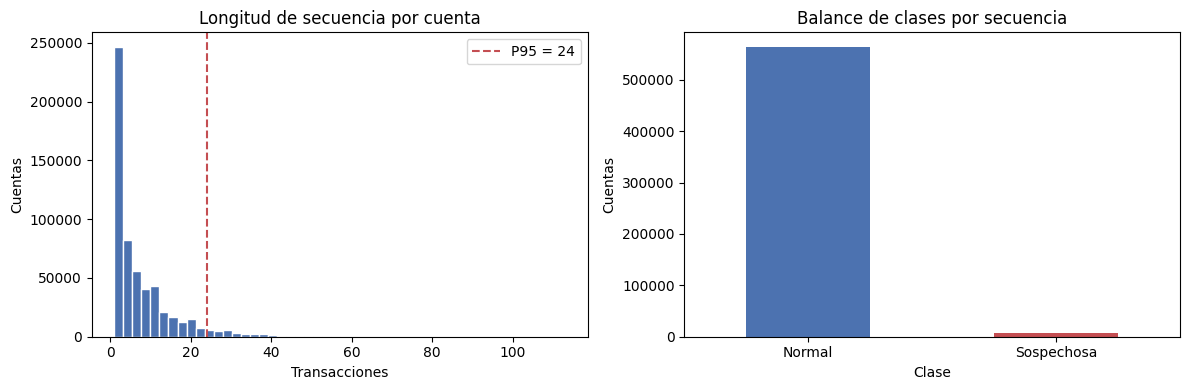

In [6]:
seq_lengths_full = df_c.groupby("nameDest", sort=False).size()
history_labels = df_c.groupby("nameDest", sort=False)["isFraud"].max()
MAX_LEN = int(seq_lengths_full.quantile(0.95))

recent_rows = df_c.groupby("nameDest", sort=False).tail(MAX_LEN)
window_labels = recent_rows.groupby("nameDest", sort=False)["isFraud"].max()
window_lengths = recent_rows.groupby("nameDest", sort=False).size()

account_summary = pd.DataFrame({
    "history_y": history_labels,
    "window_y": window_labels.reindex(history_labels.index, fill_value=0),
    "window_length": window_lengths.reindex(history_labels.index, fill_value=0),
})

dropped_positive = ((account_summary["history_y"] == 1) & (account_summary["window_y"] == 0)).sum()

print("MAX_LEN (P95):", MAX_LEN)
print(f"Cuentas analizadas: {len(account_summary):,}")
print(f"Positivas en historia completa: {int(account_summary['history_y'].sum()):,}")
print(f"Positivas en ventana visible: {int(account_summary['window_y'].sum()):,}")
print(f"Fraude fuera de la ventana: {dropped_positive:,} cuentas "
      f"({dropped_positive / account_summary['history_y'].sum():.2%} de las positivas históricas)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(seq_lengths_full, bins=50, color="#4C72B0", edgecolor="white")
axes[0].axvline(MAX_LEN, color="#C44E52", linestyle="--", label=f"P95 = {MAX_LEN}")
axes[0].set(title="Longitud de secuencia por cuenta", xlabel="Transacciones", ylabel="Cuentas")
axes[0].legend()

account_summary["window_y"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"]
)
axes[1].set(title="Balance de clases por secuencia", xlabel="Clase", ylabel="Cuentas")
axes[1].set_xticklabels(["Normal", "Sospechosa"], rotation=0)
plt.tight_layout()
plt.show()

### 1.5 Ejemplos antes del modelado

Se muestran tres secuencias normales y tres sospechosas. Los puntos rojos corresponden a transacciones etiquetadas como fraude dentro de la ventana que recibirá el modelo.

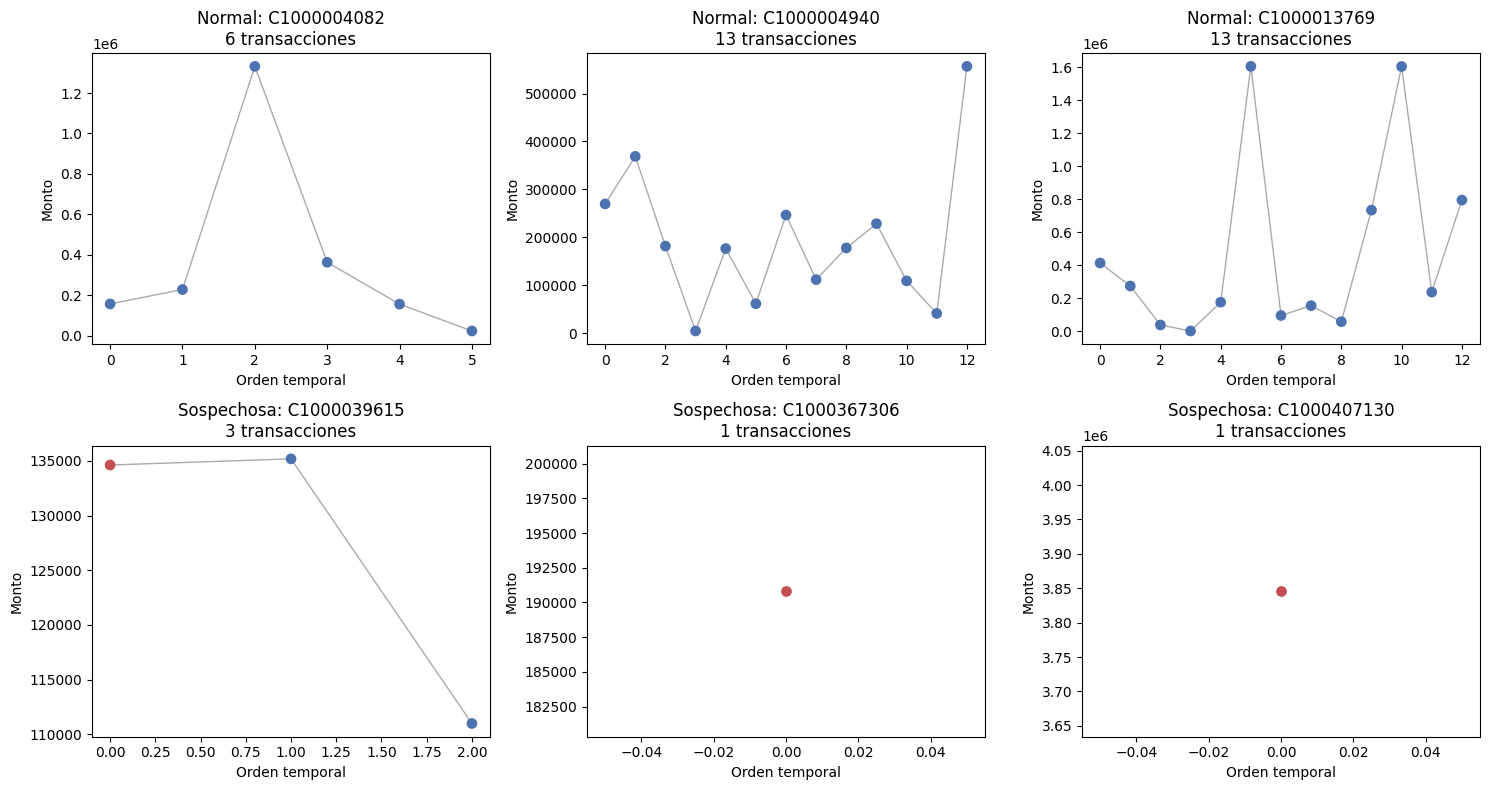

In [7]:
normal_ids = account_summary.query("window_y == 0 and window_length >= 6").index[:3]
suspicious_ids = account_summary.query("window_y == 1").index[:3]
example_ids = list(normal_ids) + list(suspicious_ids)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for ax, account_id in zip(axes.flat, example_ids):
    account = recent_rows[recent_rows["nameDest"] == account_id].sort_values("step")
    colors = np.where(account["isFraud"].to_numpy() == 1, "#C44E52", "#4C72B0")
    positions = np.arange(len(account))
    ax.plot(positions, account["amount"], color="#AAAAAA", linewidth=1)
    ax.scatter(positions, account["amount"], c=colors, s=45, zorder=3)
    label = "Sospechosa" if account["isFraud"].max() else "Normal"
    ax.set_title(f"{label}: {account_id}\n{len(account)} transacciones")
    ax.set_xlabel("Orden temporal")
    ax.set_ylabel("Monto")

plt.tight_layout()
plt.show()

### 1.6 Separación sin fuga de cuentas

La separación se realiza sobre identificadores únicos y se estratifica por el label de la ventana. Una cuenta completa pertenece exclusivamente a entrenamiento, validación o prueba. Las proporciones son 70/15/15.

In [8]:
accounts = account_summary.index.to_numpy()
labels = account_summary["window_y"].to_numpy()

train_accounts, other_accounts, _, other_y = train_test_split(
    accounts, labels, train_size=0.70, random_state=RANDOM_SEED, stratify=labels
)
val_accounts, test_accounts = train_test_split(
    other_accounts, train_size=0.50, random_state=RANDOM_SEED, stratify=other_y
)

assert not (set(train_accounts) & set(val_accounts))
assert not (set(train_accounts) & set(test_accounts))
assert not (set(val_accounts) & set(test_accounts))

for name, ids in [("Train", train_accounts), ("Validación", val_accounts), ("Prueba", test_accounts)]:
    rate = account_summary.loc[ids, "window_y"].mean()
    print(f"{name:10s}: {len(ids):,} cuentas | positivas: {rate:.2%}")

Train     : 400,372 cuentas | positivas: 1.39%
Validación: 85,794 cuentas | positivas: 1.39%
Prueba    : 85,795 cuentas | positivas: 1.39%


### 1.7 Normalización

El `StandardScaler` se ajusta únicamente con transacciones de cuentas de entrenamiento. `type_idx` se excluye porque es una categoría y se utilizará mediante un embedding.

In [9]:
train_row_mask = df_c["nameDest"].isin(train_accounts)
scaler = StandardScaler()
scaler.fit(df_c.loc[train_row_mask, NUMERIC_COLS])
df_c[NUMERIC_COLS] = scaler.transform(df_c[NUMERIC_COLS]).astype("float32")
print(f"Scaler ajustado con {int(train_row_mask.sum()):,} transacciones de train.")
del train_row_mask

Scaler ajustado con 2,943,166 transacciones de train.


### 1.8 Tensores con padding a la derecha

Las transacciones válidas ocupan las primeras posiciones y el padding queda al final. Esta disposición es necesaria para usar `pack_padded_sequence` correctamente en el GRU. La máscara y las longitudes se verifican mediante aserciones.

In [10]:
def build_sequence_tensors(account_ids, df_source, feature_cols, max_len):
    selected = df_source[df_source["nameDest"].isin(account_ids)].copy()
    selected = selected.sort_values(["nameDest", "step"], kind="mergesort")
    recent = selected.groupby("nameDest", sort=False).tail(max_len).copy()

    recent["account_idx"], ordered_accounts = pd.factorize(recent["nameDest"], sort=False)
    recent["position"] = recent.groupby("account_idx", sort=False).cumcount()

    n_accounts = len(ordered_accounts)
    X = np.zeros((n_accounts, max_len, len(feature_cols)), dtype=np.float32)
    mask = np.zeros((n_accounts, max_len), dtype=np.float32)

    rows = recent["account_idx"].to_numpy()
    cols = recent["position"].to_numpy()
    X[rows, cols] = recent[feature_cols].to_numpy(dtype=np.float32)
    mask[rows, cols] = 1.0

    y = recent.groupby("account_idx", sort=False)["isFraud"].max().to_numpy(dtype=np.float32)
    lengths = recent.groupby("account_idx", sort=False).size().to_numpy(dtype=np.int64)

    assert np.array_equal(mask.sum(axis=1).astype(np.int64), lengths)
    assert np.all(mask[np.arange(n_accounts), lengths - 1] == 1)
    short = np.flatnonzero(lengths < max_len)
    assert np.all(mask[short, lengths[short]] == 0)

    return X, mask, y, np.asarray(ordered_accounts), lengths


X_train, mask_train, y_train, order_train, lengths_train = build_sequence_tensors(
    train_accounts, df_c, FEATURE_COLS, MAX_LEN
)
X_val, mask_val, y_val, order_val, lengths_val = build_sequence_tensors(
    val_accounts, df_c, FEATURE_COLS, MAX_LEN
)
X_test, mask_test, y_test, order_test, lengths_test = build_sequence_tensors(
    test_accounts, df_c, FEATURE_COLS, MAX_LEN
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Proporción positiva:", {
    "train": float(y_train.mean()), "val": float(y_val.mean()), "test": float(y_test.mean())
})

Train: (400372, 24, 7) | Val: (85794, 24, 7) | Test: (85795, 24, 7)
Proporción positiva: {'train': 0.013932042755186558, 'val': 0.013928713276982307, 'test': 0.01392855029553175}


### 1.9 Tratamiento del desbalance

Validación y prueba conservan la distribución natural. En entrenamiento también se mantiene esa distribución y se corrige únicamente mediante `pos_weight = negativos / positivos` en `BCEWithLogitsLoss`.

No se combina `pos_weight` con un sampler balanceado, porque aplicar ambas correcciones simultáneamente sobreponderaría la clase positiva y produciría probabilidades mal calibradas.

In [11]:
positive_count = float(y_train.sum())
negative_count = float(len(y_train) - positive_count)
POS_WEIGHT = negative_count / positive_count

print(f"Positivos en train: {int(positive_count):,}")
print(f"Negativos en train: {int(negative_count):,}")
print(f"pos_weight: {POS_WEIGHT:.2f}")

Positivos en train: 5,578
Negativos en train: 394,794
pos_weight: 70.78


## Estado del Componente 1

- Secuencias ordenadas cronológicamente por cuenta receptora.
- Ventana máxima justificada con el percentil 95.
- Padding a la derecha y máscara verificadas.
- Label calculado únicamente con información visible.
- Split estratificado y sin cuentas compartidas.
- Normalización ajustada solo con train.
- Distribución de longitudes, balance y seis secuencias visualizadas.

La siguiente sección incorporará la Etapa A: autoencoder secuencial entrenado exclusivamente con cuentas normales.

## 2. Etapa A - Aprendizaje de la normalidad

La primera etapa aprende a reconstruir secuencias legítimas sin utilizar ejemplos positivos durante el entrenamiento. El supuesto es que una secuencia que se aleja del comportamiento normal tendrá mayor error de reconstrucción.

La arquitectura contiene:

1. Un embedding para el tipo de transacción.
2. Un encoder GRU que respeta las longitudes reales mediante `pack_padded_sequence`.
3. Una proyección a un vector latente comprimido.
4. Un decoder GRU que reconstruye las variables numéricas y el tipo de cada transacción.

El mejor modelo se selecciona usando únicamente la pérdida de reconstrucción de cuentas normales del conjunto de validación.

In [12]:
import copy
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.set_float32_matmul_precision("high")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
BATCH_SIZE = 1024 if USE_AMP else 256
N_TYPES = len(type_map)
NUM_FEATURES = len(NUMERIC_COLS)

print("Dispositivo:", DEVICE)
if USE_AMP:
    print("GPU:", torch.cuda.get_device_name(0))
print("Batch size:", BATCH_SIZE)

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Batch size: 1024


In [13]:
class AMLSequenceDataset(Dataset):
    def __init__(self, X, mask, y):
        # type_idx es la última columna y no se trata como variable continua.
        self.x_num = torch.from_numpy(np.ascontiguousarray(X[:, :, :-1]))
        self.x_type = torch.from_numpy(X[:, :, -1].astype(np.int64, copy=True))
        self.mask = torch.from_numpy(mask)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.x_num[index], self.x_type[index], self.mask[index], self.y[index]


train_ds = AMLSequenceDataset(X_train, mask_train, y_train)
val_ds = AMLSequenceDataset(X_val, mask_val, y_val)
test_ds = AMLSequenceDataset(X_test, mask_test, y_test)

normal_train_idx = np.flatnonzero(y_train == 0)
normal_val_idx = np.flatnonzero(y_val == 0)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": USE_AMP,
}
normal_train_loader = DataLoader(
    Subset(train_ds, normal_train_idx), shuffle=True, **loader_options
)
normal_val_loader = DataLoader(
    Subset(val_ds, normal_val_idx), shuffle=False, **loader_options
)
val_loader = DataLoader(val_ds, shuffle=False, **loader_options)
test_loader = DataLoader(test_ds, shuffle=False, **loader_options)

print(f"Etapa A train: {len(normal_train_idx):,} secuencias normales")
print(f"Etapa A validación: {len(normal_val_idx):,} secuencias normales")

# Los Dataset ya conservan los tensores necesarios.
del X_train, X_val, X_test, mask_train, mask_val, mask_test

Etapa A train: 394,794 secuencias normales
Etapa A validación: 84,599 secuencias normales


In [14]:
EMBED_DIM = 4
HIDDEN_DIM = 64
LATENT_DIM = 24
POSITION_DIM = 8


class SequenceEncoder(nn.Module):
    def __init__(self, n_types, num_features):
        super().__init__()
        self.type_embedding = nn.Embedding(n_types, EMBED_DIM)
        self.gru = nn.GRU(num_features + EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.to_latent = nn.Linear(HIDDEN_DIM, LATENT_DIM)

    def forward(self, x_num, x_type, mask, return_sequence=False):
        embedded_type = self.type_embedding(x_type)
        inputs = torch.cat([x_num, embedded_type], dim=-1)
        lengths = mask.sum(dim=1).clamp(min=1).long().cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            inputs, lengths, batch_first=True, enforce_sorted=False
        )
        packed_output, hidden = self.gru(packed)
        latent = self.to_latent(hidden[-1])

        if not return_sequence:
            return latent

        sequence_output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output, batch_first=True, total_length=mask.shape[1]
        )
        return latent, sequence_output


class SequenceDecoder(nn.Module):
    def __init__(self, max_len, n_types, num_features):
        super().__init__()
        self.max_len = max_len
        self.position_embedding = nn.Embedding(max_len, POSITION_DIM)
        self.initial_hidden = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.gru = nn.GRU(LATENT_DIM + POSITION_DIM, HIDDEN_DIM, batch_first=True)
        self.numeric_output = nn.Linear(HIDDEN_DIM, num_features)
        self.type_output = nn.Linear(HIDDEN_DIM, n_types)

    def forward(self, latent):
        batch_size = latent.shape[0]
        positions = torch.arange(self.max_len, device=latent.device)
        position_features = self.position_embedding(positions)
        position_features = position_features.unsqueeze(0).expand(batch_size, -1, -1)
        repeated_latent = latent.unsqueeze(1).expand(-1, self.max_len, -1)
        decoder_input = torch.cat([repeated_latent, position_features], dim=-1)
        hidden0 = self.initial_hidden(latent).unsqueeze(0)
        output, _ = self.gru(decoder_input, hidden0)
        return self.numeric_output(output), self.type_output(output)


class SequenceAutoencoder(nn.Module):
    def __init__(self, max_len, n_types, num_features):
        super().__init__()
        self.encoder = SequenceEncoder(n_types, num_features)
        self.decoder = SequenceDecoder(max_len, n_types, num_features)

    def forward(self, x_num, x_type, mask):
        latent = self.encoder(x_num, x_type, mask)
        numeric_hat, type_logits = self.decoder(latent)
        return latent, numeric_hat, type_logits


def masked_reconstruction_loss(numeric_hat, type_logits, x_num, x_type, mask):
    numeric_mask = mask.unsqueeze(-1)
    numeric_loss = ((numeric_hat - x_num) ** 2 * numeric_mask).sum()
    numeric_loss = numeric_loss / (numeric_mask.sum() * NUM_FEATURES + 1e-8)

    type_loss = nn.functional.cross_entropy(
        type_logits.reshape(-1, N_TYPES), x_type.reshape(-1), reduction="none"
    ).reshape(mask.shape)
    type_loss = (type_loss * mask).sum() / (mask.sum() + 1e-8)

    # La parte categórica recibe menor peso para equilibrar ambas escalas.
    return numeric_loss + 0.5 * type_loss, numeric_loss, type_loss


autoencoder = SequenceAutoencoder(MAX_LEN, N_TYPES, NUM_FEATURES).to(DEVICE)
trainable_parameters = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {trainable_parameters:,}")

Parámetros entrenables: 37,426


### 2.1 Entrenamiento sobre cuentas normales

Se usa Adam con precisión mixta en GPU. El entrenamiento se detiene si la pérdida de validación normal no mejora durante tres épocas. De esta forma, el número de épocas no se elige observando el conjunto de prueba.

In [15]:
def run_reconstruction_epoch(model, loader, optimizer=None, amp_enabled=False):
    training = optimizer is not None
    model.train(training)
    totals = np.zeros(4, dtype=np.float64)

    for x_num, x_type, mask, _ in loader:
        x_num = x_num.to(DEVICE, non_blocking=True)
        x_type = x_type.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.amp.autocast(device_type=DEVICE.type, enabled=amp_enabled):
                _, numeric_hat, type_logits = model(x_num, x_type, mask)
                loss, numeric_loss, type_loss = masked_reconstruction_loss(
                    numeric_hat, type_logits, x_num, x_type, mask
                )

            if training:
                amp_scaler.scale(loss).backward()
                amp_scaler.step(optimizer)
                amp_scaler.update()

        batch_size = len(x_num)
        totals += [loss.item() * batch_size, numeric_loss.item() * batch_size,
                   type_loss.item() * batch_size, batch_size]

    return totals[:3] / totals[3]


MAX_EPOCHS = 20
PATIENCE = 3
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
amp_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

history = {"train": [], "val": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0
training_start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    train_values = run_reconstruction_epoch(
        autoencoder, normal_train_loader, optimizer=optimizer, amp_enabled=USE_AMP
    )
    with torch.no_grad():
        val_values = run_reconstruction_epoch(
            autoencoder, normal_val_loader, optimizer=None, amp_enabled=USE_AMP
        )

    history["train"].append(train_values)
    history["val"].append(val_values)
    print(
        f"Época {epoch:02d} | train={train_values[0]:.4f} "
        f"| val={val_values[0]:.4f}"
    )

    if val_values[0] < best_val_loss - 1e-4:
        best_val_loss = float(val_values[0])
        best_state = copy.deepcopy(autoencoder.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping: la pérdida de validación dejó de mejorar.")
            break

autoencoder.load_state_dict(best_state)
training_minutes = (time.perf_counter() - training_start) / 60
print(f"Tiempo de entrenamiento Etapa A: {training_minutes:.2f} minutos")
print(f"Mejor pérdida de validación normal: {best_val_loss:.4f}")

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
torch.save(
    {
        "model_state": autoencoder.state_dict(),
        "max_len": MAX_LEN,
        "feature_cols": FEATURE_COLS,
        "type_map": type_map,
        "hidden_dim": HIDDEN_DIM,
        "latent_dim": LATENT_DIM,
    },
    ARTIFACT_DIR / "stage_a_autoencoder.pt",
)

Época 01 | train=1.2541 | val=1.0866


Época 02 | train=1.0159 | val=0.9597


Época 03 | train=0.9188 | val=0.8830


Época 04 | train=0.8602 | val=0.8362


Época 05 | train=0.8151 | val=0.7981


...

Época 16 | train=0.6392 | val=0.6330


Época 17 | train=0.6341 | val=0.6269


Época 18 | train=0.6268 | val=0.6219


Época 19 | train=0.6272 | val=0.6186


Época 20 | train=0.6146 | val=0.6179
Tiempo de entrenamiento Etapa A: 5.17 minutos
Mejor pérdida de validación normal: 0.6179


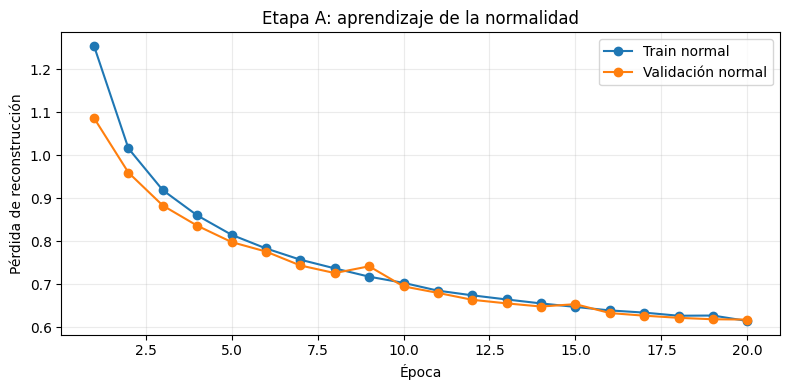

In [16]:
history_train = np.asarray(history["train"])
history_val = np.asarray(history["val"])
epochs = np.arange(1, len(history_train) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history_train[:, 0], marker="o", label="Train normal")
plt.plot(epochs, history_val[:, 0], marker="o", label="Validación normal")
plt.xlabel("Época")
plt.ylabel("Pérdida de reconstrucción")
plt.title("Etapa A: aprendizaje de la normalidad")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 2.2 Score de anomalía y selección del umbral

El score combina el error cuadrático de las variables numéricas y la entropía cruzada del tipo de transacción. El umbral se elige en validación maximizando F1 sobre la curva precision-recall. El conjunto de prueba se utiliza una sola vez después de fijar ese umbral.

In [17]:
def reconstruction_scores(model, loader):
    model.eval()
    all_scores, all_numeric, all_type, all_y = [], [], [], []

    with torch.no_grad():
        for x_num, x_type, mask, y in loader:
            x_num = x_num.to(DEVICE, non_blocking=True)
            x_type = x_type.to(DEVICE, non_blocking=True)
            mask = mask.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                _, numeric_hat, type_logits = model(x_num, x_type, mask)

                numeric_error = ((numeric_hat - x_num) ** 2 * mask.unsqueeze(-1)).sum((1, 2))
                numeric_error = numeric_error / (mask.sum(1) * NUM_FEATURES + 1e-8)

                type_error = nn.functional.cross_entropy(
                    type_logits.reshape(-1, N_TYPES), x_type.reshape(-1), reduction="none"
                ).reshape(mask.shape)
                type_error = (type_error * mask).sum(1) / (mask.sum(1) + 1e-8)
                score = numeric_error + 0.5 * type_error

            all_scores.append(score.float().cpu().numpy())
            all_numeric.append(numeric_error.float().cpu().numpy())
            all_type.append(type_error.float().cpu().numpy())
            all_y.append(y.numpy())

    return (
        np.concatenate(all_scores), np.concatenate(all_numeric),
        np.concatenate(all_type), np.concatenate(all_y)
    )


val_score, val_numeric_error, val_type_error, val_targets = reconstruction_scores(
    autoencoder, val_loader
)
test_score, test_numeric_error, test_type_error, test_targets = reconstruction_scores(
    autoencoder, test_loader
)

precision_curve, recall_curve, thresholds = precision_recall_curve(val_targets, val_score)
f1_curve = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-8)
best_index = int(np.nanargmax(f1_curve[:-1]))
ANOMALY_THRESHOLD = float(thresholds[best_index])

print(f"Umbral elegido en validación: {ANOMALY_THRESHOLD:.4f}")
print(f"F1 de validación en el umbral: {f1_curve[best_index]:.4f}")

Umbral elegido en validación: 1.0452
F1 de validación en el umbral: 0.0354


,PR-AUC,ROC-AUC,Precision,Recall,F1,TN,FP,FN,TP
Conjunto,,,,,,,,,
Validación,0.0176,0.5795,0.0219,0.0912,0.0354,79741,4858,1086,109
Prueba,0.0180,0.5761,0.0184,0.0753,0.0295,79787,4813,1105,90


Error medio en prueba:
  Normal:      0.2959
  Sospechosa:  0.3629


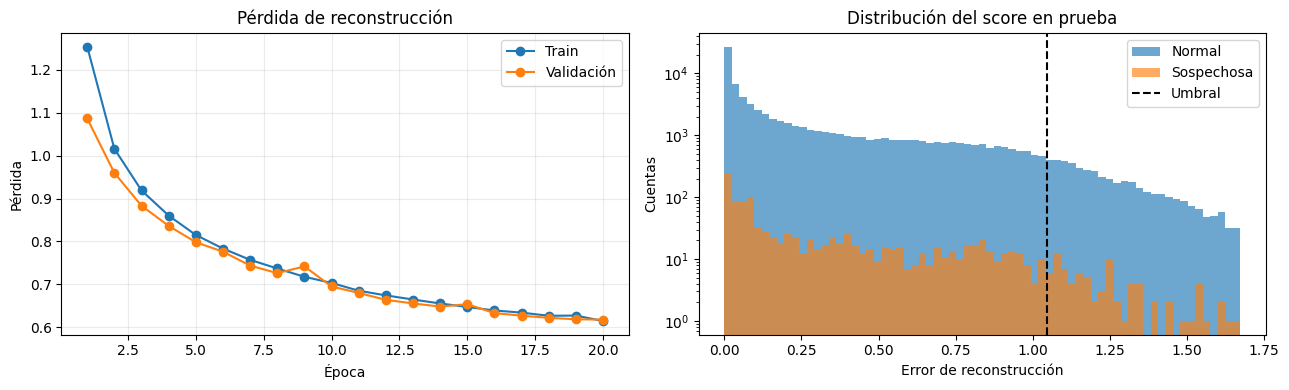

In [18]:
def anomaly_metrics(targets, scores, threshold):
    predictions = (scores >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(targets, predictions).ravel()
    return {
        "PR-AUC": average_precision_score(targets, scores),
        "ROC-AUC": roc_auc_score(targets, scores),
        "Precision": precision_score(targets, predictions, zero_division=0),
        "Recall": recall_score(targets, predictions, zero_division=0),
        "F1": f1_score(targets, predictions, zero_division=0),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


stage_a_results = pd.DataFrame(
    [
        {"Conjunto": "Validación", **anomaly_metrics(val_targets, val_score, ANOMALY_THRESHOLD)},
        {"Conjunto": "Prueba", **anomaly_metrics(test_targets, test_score, ANOMALY_THRESHOLD)},
    ]
).set_index("Conjunto")
display(stage_a_results.round(4))

print("Error medio en prueba:")
print(f"  Normal:      {test_score[test_targets == 0].mean():.4f}")
print(f"  Sospechosa:  {test_score[test_targets == 1].mean():.4f}")

upper = np.quantile(test_score, 0.995)
bins = np.linspace(0, upper, 70)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history_train[:, 0], marker="o", label="Train")
axes[0].plot(epochs, history_val[:, 0], marker="o", label="Validación")
axes[0].set(title="Pérdida de reconstrucción", xlabel="Época", ylabel="Pérdida")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].hist(test_score[test_targets == 0], bins=bins, alpha=0.65, label="Normal")
axes[1].hist(test_score[test_targets == 1], bins=bins, alpha=0.65, label="Sospechosa")
axes[1].axvline(ANOMALY_THRESHOLD, color="black", linestyle="--", label="Umbral")
axes[1].set(title="Distribución del score en prueba", xlabel="Error de reconstrucción", ylabel="Cuentas")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

checkpoint = torch.load(ARTIFACT_DIR / "stage_a_autoencoder.pt", map_location="cpu", weights_only=False)
checkpoint["anomaly_threshold"] = ANOMALY_THRESHOLD
checkpoint["scaler_mean"] = scaler.mean_
checkpoint["scaler_scale"] = scaler.scale_
torch.save(checkpoint, ARTIFACT_DIR / "stage_a_autoencoder.pt")

### Estado de la Etapa A

- El autoencoder se entrenó exclusivamente con cuentas normales.
- El encoder procesa únicamente posiciones válidas de cada secuencia.
- El modelo reconstruye variables numéricas y tipos de transacción.
- El mejor checkpoint se seleccionó con validación normal y early stopping.
- El score y el umbral se calcularon antes de consultar las métricas de prueba.
- El checkpoint guarda pesos, configuración, normalización y umbral para reutilizarlo en la Etapa B y en el MVP.

La siguiente sección construirá el clasificador supervisado y el experimento de ablación.

## 3. Etapa B - Clasificación supervisada con transferencia

El clasificador reutiliza el encoder de la Etapa A y añade atención temporal. La atención asigna un peso a cada transacción válida y permite identificar cuáles influyeron más en la decisión.

Se comparan tres variantes bajo los mismos splits y métricas:

1. **Baseline:** encoder inicializado aleatoriamente y entrenado desde cero.
2. **Transferencia:** encoder inicializado con la Etapa A, sin usar el score de anomalía.
3. **Sistema completo:** encoder preentrenado más el score fijo de reconstrucción de la Etapa A.

El score se calcula con el autoencoder congelado antes de entrenar los clasificadores. Así, el significado de la anomalía no cambia durante el fine-tuning.

In [19]:
train_eval_loader = DataLoader(train_ds, shuffle=False, **loader_options)
train_score, _, _, train_targets = reconstruction_scores(autoencoder, train_eval_loader)

# Estandarización calculada exclusivamente con train.
ANOMALY_MEAN = float(train_score.mean())
ANOMALY_STD = float(train_score.std() + 1e-8)
train_score_z = ((train_score - ANOMALY_MEAN) / ANOMALY_STD).astype(np.float32)
val_score_z = ((val_score - ANOMALY_MEAN) / ANOMALY_STD).astype(np.float32)
test_score_z = ((test_score - ANOMALY_MEAN) / ANOMALY_STD).astype(np.float32)


class SupervisedSequenceDataset(Dataset):
    def __init__(self, base_dataset, anomaly_scores):
        self.base_dataset = base_dataset
        self.anomaly_scores = torch.from_numpy(anomaly_scores)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        x_num, x_type, mask, y = self.base_dataset[index]
        return x_num, x_type, mask, y, self.anomaly_scores[index]


stage_b_train_ds = SupervisedSequenceDataset(train_ds, train_score_z)
stage_b_val_ds = SupervisedSequenceDataset(val_ds, val_score_z)
stage_b_test_ds = SupervisedSequenceDataset(test_ds, test_score_z)


def make_stage_b_train_loader():
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    return DataLoader(
        stage_b_train_ds, shuffle=True, generator=generator, **loader_options
    )


stage_b_val_loader = DataLoader(stage_b_val_ds, shuffle=False, **loader_options)
stage_b_test_loader = DataLoader(stage_b_test_ds, shuffle=False, **loader_options)

print(f"Score Etapa A en train: media={ANOMALY_MEAN:.4f}, desviación={ANOMALY_STD:.4f}")

Score Etapa A en train: media=0.2952, desviación=0.3811


In [20]:
class AttentionClassifier(nn.Module):
    def __init__(self, encoder, use_anomaly_score=False):
        super().__init__()
        self.encoder = encoder
        self.use_anomaly_score = use_anomaly_score
        self.attention = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )
        classifier_input = LATENT_DIM + HIDDEN_DIM + int(use_anomaly_score)
        self.classifier = nn.Sequential(
            nn.Linear(classifier_input, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 1),
        )

    def forward(self, x_num, x_type, mask, anomaly_score=None, return_attention=False):
        latent, sequence_output = self.encoder(
            x_num, x_type, mask, return_sequence=True
        )
        attention_logits = self.attention(sequence_output).squeeze(-1)
        attention_logits = attention_logits.masked_fill(mask == 0, -1e4)
        attention_weights = torch.softmax(attention_logits, dim=1)
        context = (sequence_output * attention_weights.unsqueeze(-1)).sum(dim=1)

        features = [latent, context]
        if self.use_anomaly_score:
            if anomaly_score is None:
                raise ValueError("El sistema completo requiere el score de la Etapa A.")
            features.append(anomaly_score.unsqueeze(-1))

        logits = self.classifier(torch.cat(features, dim=1)).squeeze(-1)
        if return_attention:
            return logits, attention_weights
        return logits


def classifier_predictions(model, loader, return_attention=False):
    model.eval()
    probabilities, targets, attentions = [], [], []
    with torch.no_grad():
        for x_num, x_type, mask, y, anomaly_score in loader:
            x_num = x_num.to(DEVICE, non_blocking=True)
            x_type = x_type.to(DEVICE, non_blocking=True)
            mask = mask.to(DEVICE, non_blocking=True)
            anomaly_score = anomaly_score.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                output = model(
                    x_num, x_type, mask, anomaly_score,
                    return_attention=return_attention
                )
                if return_attention:
                    logits, attention = output
                    attentions.append(attention.float().cpu().numpy())
                else:
                    logits = output

            probabilities.append(torch.sigmoid(logits).float().cpu().numpy())
            targets.append(y.numpy())

    result = (np.concatenate(probabilities), np.concatenate(targets))
    if return_attention:
        return result + (np.concatenate(attentions),)
    return result

### 3.1 Estrategia de entrenamiento

La pérdida es `BCEWithLogitsLoss(pos_weight=negativos/positivos)`. No se usa oversampling, por lo que la distribución natural se conserva durante el entrenamiento.

Para los modelos transferidos se aplican dos fases:

1. Dos épocas con el encoder congelado para estabilizar la cabeza recién inicializada.
2. Fine-tuning del encoder con una tasa diez veces menor que la cabeza.

El mejor checkpoint de cada variante se selecciona por PR-AUC de validación, métrica principal debido al desbalance extremo.

In [21]:
classification_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE)
)


def train_classifier_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_examples = 0
    grad_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    for x_num, x_type, mask, y, anomaly_score in loader:
        x_num = x_num.to(DEVICE, non_blocking=True)
        x_type = x_type.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        anomaly_score = anomaly_score.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits = model(x_num, x_type, mask, anomaly_score)
            loss = classification_loss(logits, y)

        grad_scaler.scale(loss).backward()
        grad_scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        grad_scaler.step(optimizer)
        grad_scaler.update()

        total_loss += loss.item() * len(y)
        total_examples += len(y)

    return total_loss / total_examples


def validation_pr_auc(model):
    probabilities, targets = classifier_predictions(model, stage_b_val_loader)
    return average_precision_score(targets, probabilities)


def fit_classifier(model, transferred, name):
    model = model.to(DEVICE)
    training_log = []
    train_loader = make_stage_b_train_loader()

    if transferred:
        for parameter in model.encoder.parameters():
            parameter.requires_grad = False
        head_parameters = list(model.attention.parameters()) + list(model.classifier.parameters())
        optimizer = torch.optim.Adam(head_parameters, lr=1e-3)

        for epoch in range(1, 2):
            loss = train_classifier_epoch(model, train_loader, optimizer)
            pr_auc = validation_pr_auc(model)
            training_log.append((f"congelado-{epoch}", loss, pr_auc))
            print(f"{name} | congelado {epoch} | loss={loss:.4f} | val PR-AUC={pr_auc:.4f}")

        for parameter in model.encoder.parameters():
            parameter.requires_grad = True
        optimizer = torch.optim.Adam(
            [
                {"params": model.encoder.parameters(), "lr": 5e-4},
                {"params": model.attention.parameters(), "lr": 1e-3},
                {"params": model.classifier.parameters(), "lr": 1e-3},
            ]
        )
        max_epochs = 16
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        max_epochs = 15

    best_pr_auc = -np.inf
    best_state = None
    patience = 4
    without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        loss = train_classifier_epoch(model, train_loader, optimizer)
        pr_auc = validation_pr_auc(model)
        training_log.append((f"ajuste-{epoch}", loss, pr_auc))
        print(f"{name} | época {epoch:02d} | loss={loss:.4f} | val PR-AUC={pr_auc:.4f}")

        if pr_auc > best_pr_auc + 1e-4:
            best_pr_auc = float(pr_auc)
            best_state = copy.deepcopy(model.state_dict())
            without_improvement = 0
        else:
            without_improvement += 1
            if without_improvement >= patience:
                print(f"{name} | early stopping")
                break

    model.load_state_dict(best_state)
    return model, training_log, best_pr_auc

In [22]:
stage_b_start = time.perf_counter()
trained_models = {}
training_logs = {}
best_validation_scores = {}

# 1. Baseline supervisado desde cero.
torch.manual_seed(RANDOM_SEED)
baseline_model = AttentionClassifier(
    SequenceEncoder(N_TYPES, NUM_FEATURES), use_anomaly_score=False
)
baseline_model, training_logs["Baseline"], best_validation_scores["Baseline desde cero"] = fit_classifier(
    baseline_model, transferred=False, name="Baseline"
)
trained_models["Baseline desde cero"] = baseline_model

# 2. Encoder preentrenado, sin score explícito.
torch.manual_seed(RANDOM_SEED)
transfer_model = AttentionClassifier(
    copy.deepcopy(autoencoder.encoder), use_anomaly_score=False
)
transfer_model, training_logs["Transferencia"], best_validation_scores["Transferencia"] = fit_classifier(
    transfer_model, transferred=True, name="Transferencia"
)
trained_models["Transferencia"] = transfer_model

# 3. Sistema completo: transferencia más score fijo de anomalía.
torch.manual_seed(RANDOM_SEED)
full_model = AttentionClassifier(
    copy.deepcopy(autoencoder.encoder), use_anomaly_score=True
)
full_model, training_logs["Sistema completo"], best_validation_scores["Transferencia + anomalía"] = fit_classifier(
    full_model, transferred=True, name="Sistema completo"
)
trained_models["Transferencia + anomalía"] = full_model

stage_b_minutes = (time.perf_counter() - stage_b_start) / 60
print(f"Tiempo total Etapa B: {stage_b_minutes:.2f} minutos")

Baseline | época 01 | loss=0.9169 | val PR-AUC=0.3735


Baseline | época 02 | loss=0.7324 | val PR-AUC=0.4587


Baseline | época 03 | loss=0.6839 | val PR-AUC=0.4878


Baseline | época 04 | loss=0.6606 | val PR-AUC=0.5118


Baseline | época 05 | loss=0.6458 | val PR-AUC=0.5261


...

Sistema completo | época 12 | loss=0.6217 | val PR-AUC=0.5372


Sistema completo | época 13 | loss=0.6137 | val PR-AUC=0.5371


Sistema completo | época 14 | loss=0.6130 | val PR-AUC=0.5301


Sistema completo | época 15 | loss=0.6079 | val PR-AUC=0.5449


Sistema completo | época 16 | loss=0.6031 | val PR-AUC=0.5417
Tiempo total Etapa B: 16.51 minutos


### 3.2 Calibración, umbral final y experimento de ablación

`pos_weight` mejora el aprendizaje de la clase minoritaria, pero hace que el `sigmoid` no sea una probabilidad calibrada. Por ello se aplica calibración de Platt sobre validación. Para cada variante se elige después el umbral que maximiza F1 y se reporta una sola evaluación sobre prueba.

PR-AUC se utiliza durante el entrenamiento porque evalúa el ranking sin fijar un umbral. La variante final se selecciona mediante F1 de validación, que representa el equilibrio operativo entre precisión y cobertura después de definir el punto de corte. Además se calcula el *lift* del 1% de cuentas con mayor riesgo.

In [23]:
def best_f1_threshold(targets, probabilities):
    precision_values, recall_values, threshold_values = precision_recall_curve(
        targets, probabilities
    )
    f1_values = 2 * precision_values * recall_values / (
        precision_values + recall_values + 1e-8
    )
    index = int(np.nanargmax(f1_values[:-1]))
    return float(threshold_values[index])


def platt_calibration(val_targets, val_scores, test_scores):
    val_scores = np.clip(val_scores, 1e-6, 1 - 1e-6)
    test_scores = np.clip(test_scores, 1e-6, 1 - 1e-6)
    val_logits = np.log(val_scores / (1 - val_scores))
    test_logits = np.log(test_scores / (1 - test_scores))
    calibrator = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
    calibrator.fit(val_logits.reshape(-1, 1), val_targets)
    val_calibrated = calibrator.predict_proba(val_logits.reshape(-1, 1))[:, 1]
    test_calibrated = calibrator.predict_proba(test_logits.reshape(-1, 1))[:, 1]
    return val_calibrated, test_calibrated, calibrator


def supervised_metrics(targets, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(targets, predictions).ravel()
    top_k = max(1, int(np.ceil(0.01 * len(targets))))
    top_indices = np.argsort(probabilities)[-top_k:]
    top_precision = targets[top_indices].mean()
    prevalence = targets.mean()

    return {
        "PR-AUC": average_precision_score(targets, probabilities),
        "ROC-AUC": roc_auc_score(targets, probabilities),
        "Umbral": threshold,
        "Precision": precision_score(targets, predictions, zero_division=0),
        "Recall": recall_score(targets, predictions, zero_division=0),
        "F1": f1_score(targets, predictions, zero_division=0),
        "Lift@1%": top_precision / prevalence,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


ablation_rows = []
model_outputs = {}

for model_name, model in trained_models.items():
    val_raw_scores, val_y_eval = classifier_predictions(model, stage_b_val_loader)
    test_raw_scores, test_y_eval = classifier_predictions(model, stage_b_test_loader)
    val_probabilities, test_probabilities, calibrator = platt_calibration(
        val_y_eval, val_raw_scores, test_raw_scores
    )
    threshold = best_f1_threshold(val_y_eval, val_probabilities)
    val_predictions = (val_probabilities >= threshold).astype(np.int8)
    metrics = supervised_metrics(test_y_eval, test_probabilities, threshold)
    ablation_rows.append({
        "Variante": model_name,
        "PR-AUC validación": average_precision_score(val_y_eval, val_probabilities),
        "F1 validación": f1_score(val_y_eval, val_predictions, zero_division=0),
        **metrics,
    })
    model_outputs[model_name] = {
        "val_probabilities": val_probabilities,
        "test_probabilities": test_probabilities,
        "threshold": threshold,
        "calibration_coef": float(calibrator.coef_[0, 0]),
        "calibration_intercept": float(calibrator.intercept_[0]),
    }

ablation_table = pd.DataFrame(ablation_rows).set_index("Variante")
display(ablation_table.round(4))

selected_model_name = max(
    ablation_rows, key=lambda row: row["F1 validación"]
)["Variante"]
print("Modelo seleccionado por F1 de validación:", selected_model_name)

,PR-AUC validación,F1 validación,PR-AUC,ROC-AUC,Umbral,Precision,Recall,F1,Lift@1%,TN,FP,FN,TP
Variante,,,,,,,,,,,,,
Baseline desde cero,0.5442,0.5341,0.5662,0.9295,0.2881,0.7057,0.4594,0.5565,47.779598,84371,229,646,549
Transferencia,0.5415,0.5365,0.5654,0.9277,0.2763,0.7198,0.4644,0.5646,48.198002,84384,216,640,555
Transferencia + anomalía,0.5449,0.5438,0.5679,0.9298,0.2633,0.7090,0.4669,0.5631,48.030701,84371,229,637,558


Modelo seleccionado por F1 de validación: Transferencia + anomalía


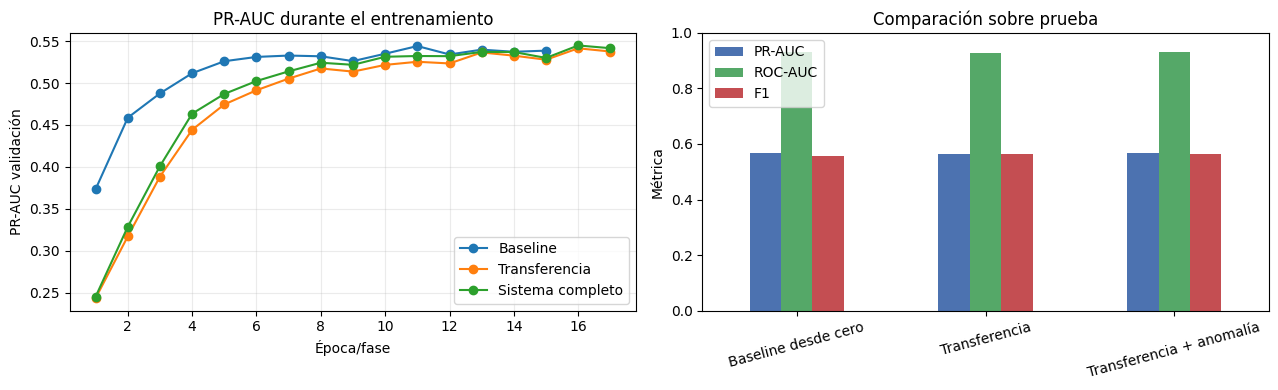

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, log in training_logs.items():
    pr_values = [row[2] for row in log]
    axes[0].plot(range(1, len(pr_values) + 1), pr_values, marker="o", label=name)
axes[0].set(title="PR-AUC durante el entrenamiento", xlabel="Época/fase", ylabel="PR-AUC validación")
axes[0].legend()
axes[0].grid(alpha=0.25)

metric_view = ablation_table[["PR-AUC", "ROC-AUC", "F1"]]
metric_view.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set(title="Comparación sobre prueba", xlabel="", ylabel="Métrica", ylim=(0, 1))
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

In [25]:
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_").replace("+", "mas")
    torch.save(
        {
            "model_state": model.state_dict(),
            "use_anomaly_score": model.use_anomaly_score,
            "threshold": model_outputs[name]["threshold"],
            "calibration_coef": model_outputs[name]["calibration_coef"],
            "calibration_intercept": model_outputs[name]["calibration_intercept"],
            "anomaly_mean": ANOMALY_MEAN,
            "anomaly_std": ANOMALY_STD,
            "max_len": MAX_LEN,
            "feature_cols": FEATURE_COLS,
            "type_map": type_map,
        },
        ARTIFACT_DIR / f"stage_b_{safe_name}.pt",
    )

print("Modelos guardados en:", ARTIFACT_DIR.resolve())

Modelos guardados en: C:\Users\mdax8\Desktop\UVG\8 Semestre\Deep Learning\Proyecto 2\DeepLearning_Proyecto2\artifacts


### Estado del Componente 2

- Etapa A entrenada solo sobre normalidad y con umbral definido en validación.
- Etapa B con atención temporal y transferencia gradual.
- Pérdida ajustada al desbalance sin alterar la distribución del DataLoader.
- Score de anomalía fijo y separado del encoder que recibe fine-tuning.
- Ablación completa contra un clasificador equivalente entrenado desde cero.
- Todos los umbrales se calibran en validación y las comparaciones usan el mismo test.

La siguiente sección utilizará los pesos de atención para analizar tres verdaderos positivos y dos errores del sistema.

## 4. Interpretabilidad mediante atención

El modelo seleccionado se interpreta a nivel de transacción. Se analizan cinco cuentas del conjunto de prueba:

- Tres casos sospechosos detectados correctamente.
- Un falso positivo.
- Un falso negativo.

Los pesos de atención no prueban causalidad, pero indican qué posiciones utilizó con mayor intensidad la cabeza clasificadora. Se complementan con el score de anomalía y con una revisión de montos, tipos y tiempos.

In [26]:
selected_model = trained_models[selected_model_name]
selected_threshold = model_outputs[selected_model_name]["threshold"]
selected_raw_scores, selected_targets, selected_attention = classifier_predictions(
    selected_model, stage_b_test_loader, return_attention=True
)
selected_raw_scores = np.clip(selected_raw_scores, 1e-6, 1 - 1e-6)
selected_logits = np.log(selected_raw_scores / (1 - selected_raw_scores))
calibrated_logits = (
    model_outputs[selected_model_name]["calibration_coef"] * selected_logits
    + model_outputs[selected_model_name]["calibration_intercept"]
)
selected_probabilities = 1 / (1 + np.exp(-calibrated_logits))
selected_predictions = (selected_probabilities >= selected_threshold).astype(np.int8)
test_lengths = test_ds.mask.sum(dim=1).numpy().astype(int)

# La atención debe sumar uno en las posiciones válidas y ser cero en padding.
np.testing.assert_allclose(selected_attention.sum(axis=1), 1.0, atol=1e-4)
for row, length in enumerate(test_lengths[:1000]):
    assert np.all(selected_attention[row, length:] < 1e-6)

eligible = test_lengths >= 3
tp_candidates = np.flatnonzero(
    (selected_targets == 1) & (selected_predictions == 1) & eligible
)
fp_candidates = np.flatnonzero(
    (selected_targets == 0) & (selected_predictions == 1) & eligible
)
fn_candidates = np.flatnonzero(
    (selected_targets == 1) & (selected_predictions == 0) & eligible
)

# Casos correctos y falsa alarma de mayor confianza; falso negativo más cercano al umbral.
tp_selected = tp_candidates[np.argsort(selected_probabilities[tp_candidates])[-3:]][::-1]
fp_selected = fp_candidates[np.argsort(selected_probabilities[fp_candidates])[-1:]][::-1]
fn_selected = fn_candidates[np.argsort(selected_probabilities[fn_candidates])[-1:]][::-1]
case_indices = np.concatenate([tp_selected, fp_selected, fn_selected])
case_types = ["Verdadero positivo"] * 3 + ["Falso positivo", "Falso negativo"]

assert len(case_indices) == 5
print("Modelo interpretado:", selected_model_name)
print("Umbral:", round(selected_threshold, 4))
print("Índices seleccionados:", case_indices.tolist())

Modelo interpretado: Transferencia + anomalía
Umbral: 0.2633
Índices seleccionados: [84805, 84856, 8373, 13765, 28573]


In [27]:
def account_window(account_id):
    return (
        df_c[df_c["nameDest"] == account_id]
        .sort_values("step")
        .tail(MAX_LEN)
        .copy()
        .reset_index(drop=True)
    )


case_details = {}
summary_rows = []

for case_type, dataset_index in zip(case_types, case_indices):
    account_id = order_test[dataset_index]
    transactions = account_window(account_id)
    length = len(transactions)
    weights = selected_attention[dataset_index, :length]
    transactions["attention"] = weights
    transactions["position"] = np.arange(length)
    case_details[account_id] = transactions

    entropy = 0.0
    if length > 1:
        entropy = float(-(weights * np.log(weights + 1e-12)).sum() / np.log(length))
    top_row = transactions.iloc[int(np.argmax(weights))]
    summary_rows.append(
        {
            "Caso": case_type,
            "Cuenta": account_id,
            "Transacciones": length,
            "Probabilidad Etapa B": selected_probabilities[dataset_index],
            "Score anomalía Etapa A": test_score[dataset_index],
            "Atención máxima": weights.max(),
            "Entropía atención": entropy,
            "Posición principal": int(top_row["position"]),
            "Tipo principal": top_row["type"],
            "Monto principal": top_row["amount"],
        }
    )

case_summary = pd.DataFrame(summary_rows)
display(case_summary.round(4))
case_summary.to_csv(ARTIFACT_DIR / "interpretability_cases.csv", index=False)

,Caso,Cuenta,Transacciones,Probabilidad Etapa B,Score anomalía Etapa A,Atención máxima,Entropía atención,Posición principal,Tipo principal,Monto principal
0,Verdadero positivo,C977281429,24,0.9998,1.4456,0.9995,0.0016,14,CASH_OUT,8.752000e+06
1,Verdadero positivo,C978277137,21,0.9998,0.9523,0.9948,0.0149,20,CASH_OUT,3.191058e+06
2,Verdadero positivo,C1185406486,12,0.9998,0.9559,0.9930,0.0203,0,TRANSFER,4.454632e+06
3,Falso positivo,C1307220530,19,0.9998,0.6513,0.9901,0.0255,15,CASH_OUT,1.894721e+06
4,Falso negativo,C1641312686,5,0.2601,0.2185,0.9976,0.0123,4,CASH_OUT,4.149735e+05


### 4.1 Mapas de calor

Cada fila representa una cuenta y cada columna una transacción en orden temporal. Un color más oscuro indica mayor peso de atención. Las estrellas marcan transacciones etiquetadas como fraude por PaySim.

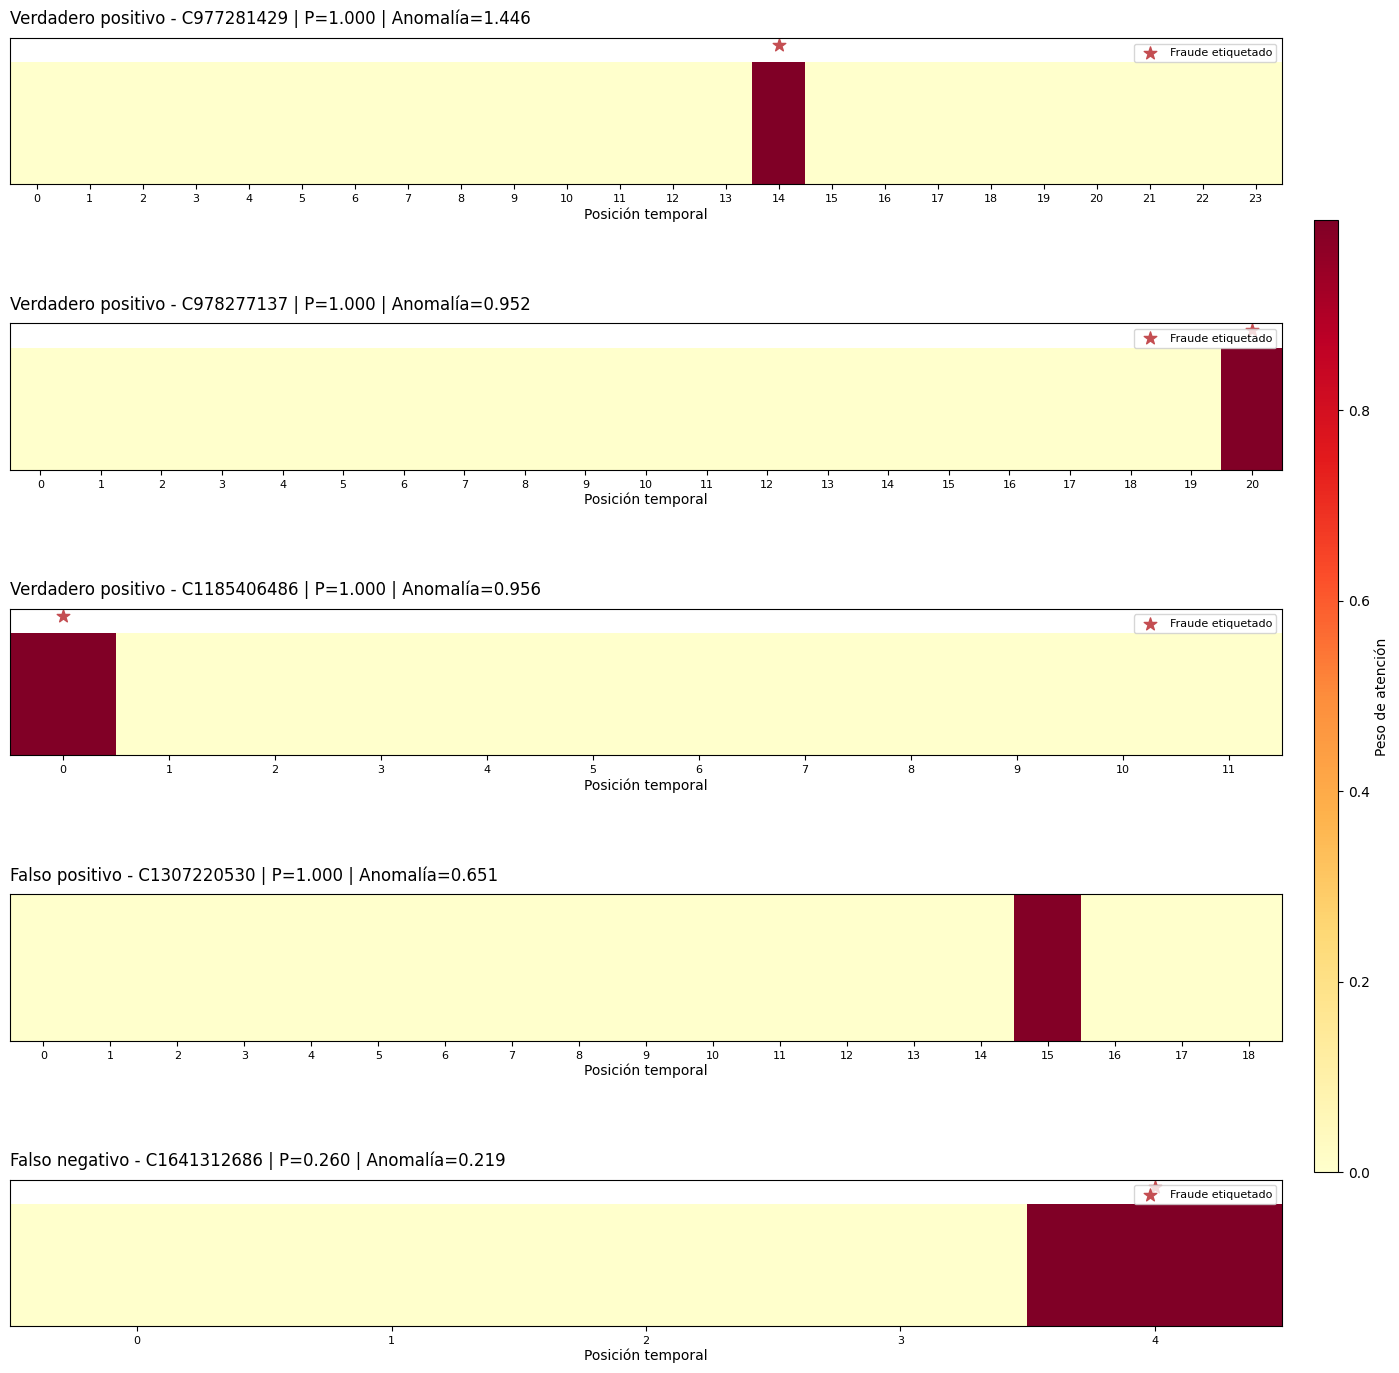

In [28]:
fig, axes = plt.subplots(5, 1, figsize=(16, 14))
global_max_attention = max(
    case_details[account_id]["attention"].max() for account_id in case_details
)

for ax, row in zip(axes, summary_rows):
    account_id = row["Cuenta"]
    transactions = case_details[account_id]
    weights = transactions["attention"].to_numpy()
    image = ax.imshow(
        weights.reshape(1, -1), aspect="auto", cmap="YlOrRd",
        vmin=0, vmax=global_max_attention
    )
    labels = [str(i) for i in transactions["position"]]
    ax.set_xticks(np.arange(len(transactions)), labels=labels, fontsize=8)
    ax.set_yticks([])
    ax.set_xlabel("Posición temporal", labelpad=2)
    ax.set_title(
        f"{row['Caso']} - {account_id} | "
        f"P={row['Probabilidad Etapa B']:.3f} | Anomalía={row['Score anomalía Etapa A']:.3f}",
        loc="left", pad=10,
    )
    fraud_positions = transactions.loc[transactions["isFraud"] == 1, "position"].to_numpy()
    if len(fraud_positions):
        ax.scatter(fraud_positions, np.full(len(fraud_positions), -0.65), marker="*", s=90,
                   color="#C44E52", clip_on=False, label="Fraude etiquetado")
        ax.legend(loc="upper right", fontsize=8)

fig.subplots_adjust(hspace=0.95, right=0.92, top=0.97, bottom=0.05)
color_axis = fig.add_axes([0.94, 0.16, 0.015, 0.68])
fig.colorbar(image, cax=color_axis, orientation="vertical", label="Peso de atención")
plt.show()

### 4.2 Análisis transaccional de los cinco casos

Para cada cuenta se muestran las cinco transacciones con mayor atención y una explicación generada a partir de las señales observadas. La explicación se limita a describir evidencia del modelo; no afirma que una persona cometió lavado de dinero.

In [29]:
def natural_language_explanation(case_type, dataset_index, transactions):
    probability = float(selected_probabilities[dataset_index])
    anomaly = float(test_score[dataset_index])
    top = transactions.sort_values("attention", ascending=False).iloc[0]
    concentration = float(top["attention"])

    signals = []
    if top["delta_t_hours"] <= 1 and top["position"] > 0:
        signals.append("ocurrió con menos de dos horas respecto a la operación anterior")
    if abs(top["amount_vs_history"]) > 1:
        signals.append("su monto se alejó del comportamiento previo de la cuenta")
    if top["type"] in ("TRANSFER", "CASH_OUT"):
        signals.append(f"fue una operación {top['type']}")
    if not signals:
        signals.append("combinó monto, momento y tipo de forma poco habitual para la secuencia")

    attention_text = (
        "La atención estuvo concentrada" if concentration >= 0.50
        else "La atención se distribuyó entre varias operaciones"
    )
    evidence = "; ".join(signals)

    if case_type == "Verdadero positivo":
        conclusion = "El modelo y la etiqueta coinciden en que la cuenta amerita revisión."
    elif case_type == "Falso positivo":
        conclusion = (
            "La secuencia no tiene fraude etiquetado; el patrón puede corresponder a una "
            "operación legítima atípica y requiere revisión humana antes de escalarse."
        )
    else:
        conclusion = (
            "La cuenta sí contiene fraude etiquetado, pero la probabilidad quedó debajo del "
            "umbral; la señal sospechosa no dominó suficientemente el resto de la secuencia."
        )

    return (
        f"{attention_text} en la transacción {int(top['position'])}, que recibió "
        f"{concentration:.1%} del peso: {evidence}. La Etapa B asignó una probabilidad "
        f"de {probability:.1%} y la Etapa A un score de {anomaly:.3f}. {conclusion}"
    )


for case_type, dataset_index in zip(case_types, case_indices):
    account_id = order_test[dataset_index]
    transactions = case_details[account_id]
    print(f"\n{case_type} - {account_id}")
    display(
        transactions[
            ["position", "step", "type", "amount", "delta_t_hours", "isFraud", "attention"]
        ]
        .sort_values("attention", ascending=False)
        .head(5)
        .round(4)
    )
    print(natural_language_explanation(case_type, dataset_index, transactions))


Verdadero positivo - C977281429


,position,step,type,amount,delta_t_hours,isFraud,attention
14,14,224,CASH_OUT,8.752000e+06,40.0,1,0.9995
3,3,119,CASH_OUT,1.806341e+04,79.0,0,0.0002
11,11,178,CASH_OUT,3.621061e+05,0.0,0,0.0001
0,0,35,CASH_OUT,2.926650e+05,0.0,0,0.0001
2,2,40,CASH_OUT,2.820159e+05,3.0,0,0.0000


La atención estuvo concentrada en la transacción 14, que recibió 100.0% del peso: su monto se alejó del comportamiento previo de la cuenta; fue una operación CASH_OUT. La Etapa B asignó una probabilidad de 100.0% y la Etapa A un score de 1.446. El modelo y la etiqueta coinciden en que la cuenta amerita revisión.

Verdadero positivo - C978277137


,position,step,type,amount,delta_t_hours,isFraud,attention
20,20,730,CASH_OUT,3.191058e+06,324.0,1,0.9948
4,4,119,CASH_IN,1.460783e+05,78.0,0,0.0014
6,6,158,CASH_OUT,3.325991e+05,22.0,0,0.0006
15,15,308,CASH_IN,5.762186e+05,1.0,0,0.0005
7,7,165,CASH_IN,2.366886e+05,7.0,0,0.0005


La atención estuvo concentrada en la transacción 20, que recibió 99.5% del peso: su monto se alejó del comportamiento previo de la cuenta; fue una operación CASH_OUT. La Etapa B asignó una probabilidad de 100.0% y la Etapa A un score de 0.952. El modelo y la etiqueta coinciden en que la cuenta amerita revisión.

Verdadero positivo - C1185406486


...

La atención estuvo concentrada en la transacción 0, que recibió 99.3% del peso: fue una operación TRANSFER. La Etapa B asignó una probabilidad de 100.0% y la Etapa A un score de 0.956. El modelo y la etiqueta coinciden en que la cuenta amerita revisión.

Falso positivo - C1307220530


,position,step,type,amount,delta_t_hours,isFraud,attention
15,15,214,CASH_OUT,1.894721e+06,4.0,0,0.9901
18,18,398,CASH_OUT,5.638294e+05,41.0,0,0.0038
13,13,209,CASH_OUT,5.428622e+05,24.0,0,0.0016
6,6,140,CASH_OUT,2.669289e+05,1.0,0,0.0013
7,7,154,CASH_OUT,3.904004e+05,14.0,0,0.0009


La atención estuvo concentrada en la transacción 15, que recibió 99.0% del peso: su monto se alejó del comportamiento previo de la cuenta; fue una operación CASH_OUT. La Etapa B asignó una probabilidad de 100.0% y la Etapa A un score de 0.651. La secuencia no tiene fraude etiquetado; el patrón puede corresponder a una operación legítima atípica y requiere revisión humana antes de escalarse.

Falso negativo - C1641312686


,position,step,type,amount,delta_t_hours,isFraud,attention
4,4,601,CASH_OUT,414973.468750,153.0,1,0.9976
2,2,376,CASH_OUT,261491.843750,45.0,0,0.0013
0,0,326,CASH_OUT,165100.437500,0.0,0,0.0007
3,3,448,CASH_IN,233478.296875,72.0,0,0.0003
1,1,331,CASH_OUT,16940.939453,5.0,0,0.0002


La atención estuvo concentrada en la transacción 4, que recibió 99.8% del peso: fue una operación CASH_OUT. La Etapa B asignó una probabilidad de 26.0% y la Etapa A un score de 0.219. La cuenta sí contiene fraude etiquetado, pero la probabilidad quedó debajo del umbral; la señal sospechosa no dominó suficientemente el resto de la secuencia.


### Conclusiones de interpretabilidad

Los casos correctos muestran si el modelo concentra atención en operaciones puntuales o combina evidencia distribuida. El falso positivo permite identificar patrones legítimos que se parecen a una alerta, mientras el falso negativo muestra situaciones donde una operación sospechosa se diluye dentro del historial.

Estas explicaciones son apoyo para priorización, no una decisión regulatoria automática. En un sistema real, el oficial de cumplimiento debe revisar la secuencia junto con información KYC, origen y destino geográfico, listas PEP y documentación del cliente.